In [5]:
# EXPECTATION DECIDER

## Integrated Probability Analysis Report

### Student Performance Analysis

#This project analyzes the probability patterns of 200 students using:
#- Study Hours
# Attendance
#- Group Discussion Participation
#- Previous Test Score
#- Final Exam Result

#The project applies probability, random variables, probability distributions,
#Venn diagrams, contingency tables, joint probability, marginal probability,
#conditional probability, and relationship analysis.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import comb
from scipy.stats import hypergeom

In [40]:
df=pd.read_csv("/content/expectation_decider_students_200.csv")

In [10]:
df.shape

(200, 6)

(200, 6)

In [12]:
df

,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,1,11,82,Yes,75,Pass
1,2,9,85,Yes,65,Pass
2,3,12,91,Yes,73,Pass
3,4,15,91,No,76,Pass
4,5,9,61,No,60,Fail
...,...,...,...,...,...,...
195,196,11,72,Yes,57,Pass
196,197,6,57,Yes,45,Fail
197,198,10,94,No,56,Pass
198,199,10,77,No,55,Fail


In [13]:
df.describe()

,student_id,study_hours,attendance,previous_test_score
count,200.000000,200.0000,200.000000,200.000000
mean,100.500000,9.3600,78.810000,65.240000
std,57.879185,3.2206,11.017296,12.388696
min,1.000000,2.0000,50.000000,35.000000
25%,50.750000,7.0000,71.000000,57.000000
50%,100.500000,9.5000,79.000000,64.500000
75%,150.250000,11.0000,86.000000,74.000000
max,200.000000,18.0000,100.000000,98.000000




### What is Probability?

Probability is the measure of how likely an event is to occur.

The value of probability lies between 0 and 1.

Formula:

P(E) = Favourable Outcomes / Total Outcomes

A probability of 0 means the event is impossible, while a probability of 1
means the event is certain.

### Probability Event Examples

1. Event A: A randomly selected student passes the final exam.
2. Event B: A randomly selected student studies more than 10 hours per week.
3. Event C: A randomly selected student attends more than 80% of classes.


In [ ]:
total_students = len(df)

pass_count = (df["final_exam_pass"] == "Pass").sum()


study_more_10 = (df["study_hours"] > 10).sum()
attendance_more_80 = (df["attendance"] > 80).sum()


print("Total Students:", total_students)
print("Pass:", pass_count)
print("Study > 10 hours:", study_more_10)
print("Attendance > 80%:", attendance_more_80)


Total Students: 200
Pass: 120
Study > 10 hours: 73
Attendance > 80%: 90


## 2. Types of Events

### Empirical Probability  ## theorectical probability

identify  one emperical probability and one theorectial probablity  from dataset.



In [ ]:
empirical_pass_probability = pass_count / total_students

print("Empirical Probability of Passing:", empirical_pass_probability)
print("Percentage:", empirical_pass_probability * 100, "%")

Empirical Probability of Passing: 0.6
Percentage: 60.0 %


the probability of students passes is 0.6

### Theoretical Probability

Let X be the number of students who pass among 3 randomly selected students.

There are:
- 200 total students
- 120 passing students
- 80 failing students

We calculate the probability that exactly 2 out of 3 selected students pass.


In [ ]:
N = 200
K = 120
n = 3
x = 2

theoretical_probability = (
    comb(K, x) * comb(N - K, n - x)
) / comb(N, n)

print("P(X = 2):", theoretical_probability)
print("Percentage:", theoretical_probability * 100, "%")

P(X = 2): 0.43490178163544996
Percentage: 43.490178163544996 %


P(X = 2): 0.43490178163544996
Percentage: 43.490178163544996 %


## 3. Random Variable & Probability Distribution

Let X = Number of students who pass the final exam out of 3 randomly selected students.

The possible values of X are:

### X = 0, 1, 2, 3

In [15]:
N = 200
K = 120
n = 3

x_values = [0, 1, 2, 3]
probabilities = []

for x in x_values:
    p = (comb(K, x) * comb(N-K, n-x)) / comb(N, n)
    probabilities.append(p)

distribution = pd.DataFrame({
    "X": x_values,
    "P(X)": probabilities
})

distribution

,X,P(X)
0,0,0.062555
1,1,0.288716
2,2,0.434902
3,3,0.213827


check probability total.

In [16]:
print("Sum of probabilities:", sum(probabilities))

Sum of probabilities: 1.0


FIND MEAN

In [17]:
mean_X = sum(x * p for x, p in zip(x_values, probabilities))

print("Mean of X:", mean_X)

Mean of X: 1.8


FIND VARIANCE


In [18]:
mean_X_squared = sum((x ** 2) * p for x, p in zip(x_values, probabilities))

variance_X = mean_X_squared - mean_X ** 2

print("Variance of X:", variance_X)

Variance of X: 0.712763819095477


### Interpretation

The mean of X is 1.8.

This means that when 3 students are randomly selected, the expected number
of students passing the exam is 1.8.

The variance is approximately 0.7128, which measures the spread of the
number of passing students around the mean.

vein diagram

## 4. Venn Diagram in Probability

Set A = Students who study more than 10 hours per week.

Set B = Students who attend more than 80% of classes.

The intersection A ∩ B represents students who satisfy both conditions.

In [19]:
A = df["study_hours"] > 10
B = df["attendance"] > 80

A_only = (A & ~B).sum()
B_only = (~A & B).sum()
both = (A & B).sum()
neither = (~A & ~B).sum()

print("A - Study > 10 hours:", A.sum())
print("B - Attendance > 80%:", B.sum())
print("A only:", A_only)
print("B only:", B_only)
print("A intersection B:", both)
print("Neither:", neither)

A - Study > 10 hours: 73
B - Attendance > 80%: 90
A only: 41
B only: 58
A intersection B: 32
Neither: 69


In [20]:
from matplotlib_venn import venn2


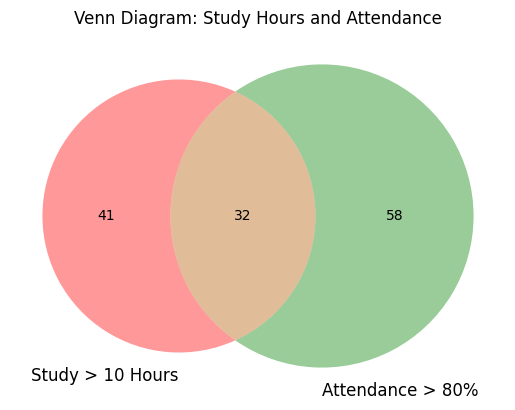

In [21]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

venn2(
    subsets=(A_only, B_only, both),
    set_labels=("Study > 10 Hours", "Attendance > 80%")
)

plt.title("Venn Diagram: Study Hours and Attendance")
plt.show()

## 5. Contingency Table & Probability Calculations

We analyze the relationship between group discussion participation
and final examination result.

In [22]:
contingency_table = pd.crosstab(
    df["group_discussion"],
    df["final_exam_pass"],
    margins=True
)

contingency_table

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,44,35,79
Yes,36,85,121
All,80,120,200


joint probability

In [26]:
total_students = len(df)

joint_count = (
    (df["group_discussion"] == "Yes") &
    (df["final_exam_pass"] == "Pass")
).sum()

joint_probability = joint_count / total_students

print("Students who participated AND passed:", joint_count)
print("Joint Probability:", joint_probability)
print("Percentage:", joint_probability * 100, "%")

Students who participated AND passed: 85
Joint Probability: 0.425
Percentage: 42.5 %


MARGINAL PROBABILITY

In [29]:
pass_count = (df["final_exam_pass"] == "Pass").sum()
marginal_probability = pass_count / total_students

print("Marginal Probability of Passing:", marginal_probability)
print("Percentage:", marginal_probability * 100, "%")

Marginal Probability of Passing: 0.6
Percentage: 60.0 %


Conditional Probability

Question:

Probability of passing given participation in group discussion.

Formula:

P(Pass∣Yes)=
Pass AND Yes/yes
	​


In [30]:
yes_count = (df["group_discussion"] == "Yes").sum()

conditional_probability = joint_count / yes_count

print("P(Pass | Group Discussion = Yes):", conditional_probability)
print("Percentage:", conditional_probability * 100, "%")

P(Pass | Group Discussion = Yes): 0.7024793388429752
Percentage: 70.24793388429752 %


# 6. Understanding Relationships

This section interprets the conditional probability and determines whether
group discussion participation and passing the final exam are independent,
dependent, or mutually exclusive events.

In [32]:
print("Overall Probability of Passing:", marginal_probability)
print("Conditional Probability of Passing given Group Discussion:",
      conditional_probability)

Overall Probability of Passing: 0.6
Conditional Probability of Passing given Group Discussion: 0.7024793388429752


### Interpretation of Conditional Probability

The overall probability of passing the exam is 60%.

Among students who participated in group discussions, the probability of
passing was 70.25%.

This means that students who participated in group discussions had a higher
observed pass probability than the overall student population.

INDEPENDENT OR DEPENDENT

In [33]:
p_pass = marginal_probability
p_pass_given_discussion = conditional_probability

if np.isclose(p_pass, p_pass_given_discussion):
    relationship = "Independent"
else:
    relationship = "Dependent"

print("P(Pass):", p_pass)
print("P(Pass | Group Discussion = Yes):", p_pass_given_discussion)
print("Relationship:", relationship)

P(Pass): 0.6
P(Pass | Group Discussion = Yes): 0.7024793388429752
Relationship: Dependent


MUTUAL EXCLUSIVITY

In [35]:
both_events = (
    (df["group_discussion"] == "Yes") &
    (df["final_exam_pass"] == "Pass")
).sum()

print("Students who participated AND passed:", both_events)

if both_events == 0:
    print("The events are mutually exclusive.")
else:
    print("The events are NOT mutually exclusive.")

Students who participated AND passed: 85
The events are NOT mutually exclusive.


### Final Relationship Conclusion

Group discussion participation and passing the exam are dependent events.

Reason:

P(Pass) = 0.60

P(Pass | Group Discussion = Yes) = 0.7025

Since these probabilities are different, the events are dependent.

They are not mutually exclusive because 85 students both participated in
group discussions and passed the exam.

# 7. Bayes Theorem Application

Bayes' Theorem is used to find the probability of an event given another
related event.

Let:

P = Student passes the exam
F = Student fails the exam
H = Student has high attendance (>80%)

Given:

P(H | P) = 0.70
P(H | F) = 0.40
P(H) = 0.60

APPLY BAYES THEOREM
FORMULA:-  P(P∣H)=P(H∣P)P(P)​/P(H)

In [39]:
p_B_given_P = 0.70      # P(B | A)
p_B_given_F = 0.40  # P(B | not A)
p_C = 0.60              # P(B)

# P(B) = P(B | A) * P(A) + P(B | not A) * (1 - P(A))
p_A = (p_C - p_B_given_F) / (p_B_given_P - p_B_given_F)
p_F = 1 - p_A

print(f"P(A) [Pass]: {p_A:.4f}")
print(f"P(B) [Fail]: {p_F:.4f}")

# P(A | B) = [P(B | A) * P(A)] / P(B)
p_A_given_B = (p_B_given_P * p_A) / p_C

print(f"P(A | B) [Pass | High Attendance]: {p_A_given_B:.4f} ({p_A_given_B:.2%})")

P(A) [Pass]: 0.6667
P(B) [Fail]: 0.3333
P(A | B) [Pass | High Attendance]: 0.7778 (77.78%)


### Bayes Theorem Calculation

Given:

P(High Attendance | Pass) = 0.70

P(High Attendance | Fail) = 0.40

P(High Attendance) = 0.60

First, find P(Pass):

P(High) = P(High | Pass)P(Pass) + P(High | Fail)P(Fail)

0.60 = 0.70P(Pass) + 0.40(1 - P(Pass))

0.60 = 0.70P(Pass) + 0.40 - 0.40P(Pass)

0.20 = 0.30P(Pass)

P(Pass) = 0.6667

Therefore:

P(Pass) = 66.67%

Now apply Bayes' Theorem:

P(Pass | High Attendance)
= [P(High Attendance | Pass) × P(Pass)] / P(High Attendance)

= (0.70 × 0.6667) / 0.60

= 0.7778

Therefore:

P(Pass | High Attendance) = 77.78%